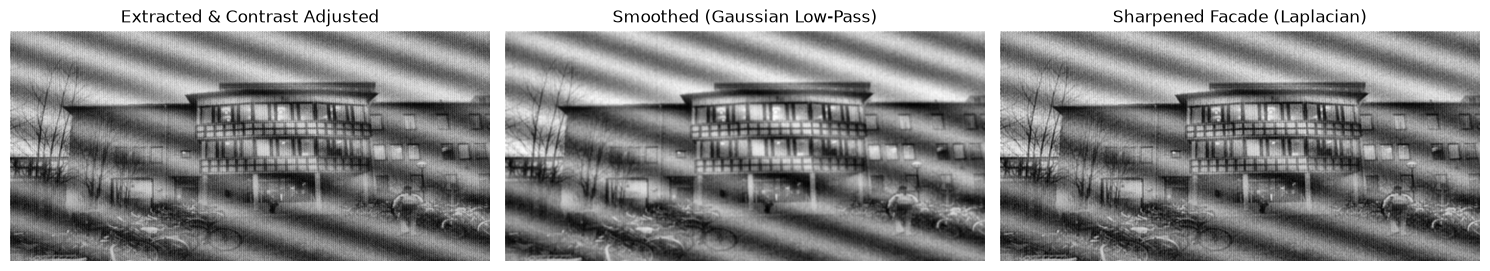

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\Dev Radia\Pictures\Screenshots\image4.png"
raw_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if raw_image is None:
    print("Error: Image not found. Check the path!")
else:
    if len(raw_image.shape) == 3 and raw_image.shape[2] == 4:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGRA2GRAY)
    elif len(raw_image.shape) == 3:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)
    else:
        image = raw_image

    norm_image = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(norm_image)

    smoothed = cv2.GaussianBlur(contrast_enhanced, (5, 5), 1.0)

    sharpening_kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32)
    sharpened = cv2.filter2D(smoothed, -1, sharpening_kernel)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(contrast_enhanced, cmap="gray")
    plt.title("Extracted & Contrast Adjusted")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(smoothed, cmap="gray")
    plt.title("Smoothed (Gaussian Low-Pass)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened, cmap="gray")
    plt.title("Sharpened Facade (Laplacian)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()